In [1]:
import os
import warnings
import itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import time
timestr = time.strftime("%Y%m%d-%H%M%S")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold


# Exploration

In [2]:
from google.colab import drive
drive.mount('/content/drive')
# list files in the folder
print(os.listdir("/content/drive/MyDrive/DMT_data"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test_set_VU_DM.csv', 'training_set_VU_DM.csv', 'DMT_data']


In [3]:
!ln -s "/content/drive/MyDrive/DMT_data" /content/DMT_data
# This should now show your data
!ls /content/DMT_data

ln: failed to create symbolic link '/content/DMT_data/DMT_data': File exists
DMT_data  test_set_VU_DM.csv  training_set_VU_DM.csv


Plot style

In [4]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.05,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"

## Read data

In [5]:
data_path = '/content/DMT_data'
train_file = os.path.join(data_path, 'training_set_VU_DM.csv')
test_file = os.path.join(data_path, 'test_set_VU_DM.csv')

train_df = pd.read_csv(train_file)
df = train_df.copy()
display(df.head())
#test = pd.read_csv(test_file)

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [6]:
'''def get_datetime(data):
    data['month'] = data['date_time'].dt.month
    data['day_of_week'] = data['date_time'].dt.dayofweek
    data['hour'] = data['date_time'].dt.hour
    return data

df = get_datetime(df)
# booking distribution by month
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['booking_bool'] == 1], x='month')
plt.title('Distribution of Bookings by Month')
plt.show()'''

"def get_datetime(data):\n    data['month'] = data['date_time'].dt.month\n    data['day_of_week'] = data['date_time'].dt.dayofweek\n    data['hour'] = data['date_time'].dt.hour\n    return data\n\ndf = get_datetime(df)\n# booking distribution by month\nplt.figure(figsize=(10, 5))\nsns.countplot(data=df[df['booking_bool'] == 1], x='month')\nplt.title('Distribution of Bookings by Month')\nplt.show()"

### Nulls

In [7]:
#df.columns.tolist()
df.isnull().sum()

,0
srch_id,0
date_time,0
site_id,0
visitor_location_country_id,0
visitor_hist_starrating,4706481
visitor_hist_adr_usd,4705359
prop_country_id,0
prop_id,0
prop_starrating,0
prop_review_score,7364


In [8]:
# % of missing values per column
missing_col_pct = (df.isnull().sum() / len(df)) * 100

# descending order sort
missing_col_pct = missing_col_pct.sort_values(ascending=False)

# only columns with some missing data
display(missing_col_pct[missing_col_pct > 0])

,0
comp1_rate_percent_diff,98.095353
comp6_rate_percent_diff,98.060362
comp1_rate,97.581250
comp1_inv,97.387053
comp4_rate_percent_diff,97.356256
gross_bookings_usd,97.208949
comp7_rate_percent_diff,97.206428
comp6_rate,95.156511
visitor_hist_starrating,94.920364
visitor_hist_adr_usd,94.897735


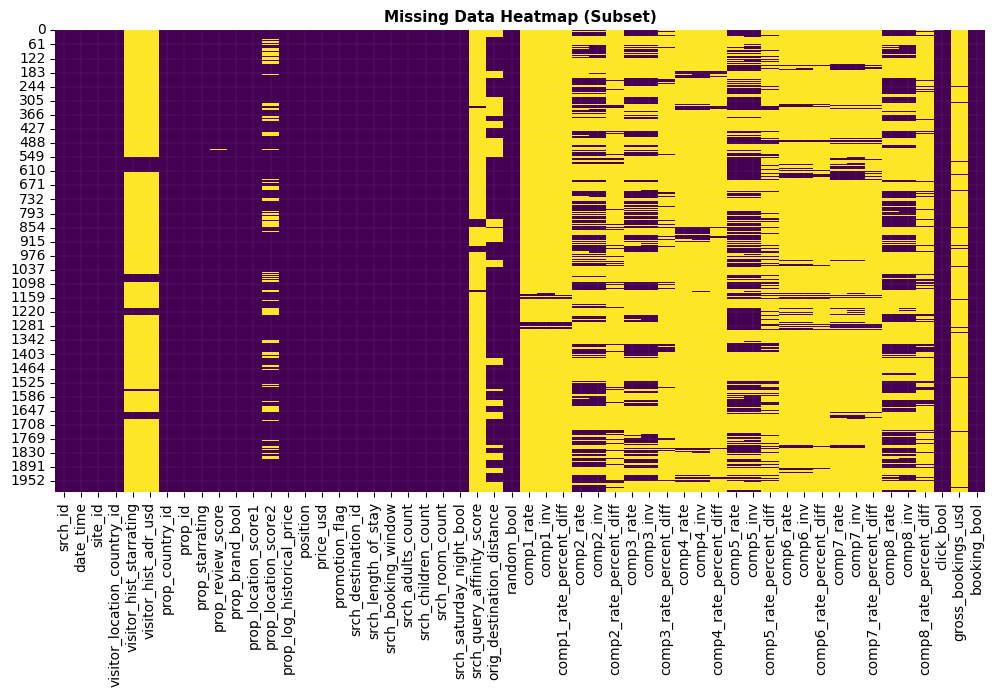

In [9]:
# visualise the first 2000 rows to see if there is any clustering in the missing data
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:2000].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap (Subset)")
plt.show()

interpretation: yellow is missing data, purple is where data is present. Where both columns are yellow - both feautres are not present.

In [10]:
# 1. Check if gross_bookings_usd is missing when booking_bool is 0
missing_logic = df.groupby('booking_bool')['gross_bookings_usd'].apply(lambda x: x.isnull().mean() * 100)
print(f"Percentage of missing 'gross_bookings_usd' by 'booking_bool':\n{missing_logic}")
print("---")

# 3. Analyze competitor rate sparsity
# Count how many competitor columns have data per row
comp_rate_cols = [c for c in df.columns if 'rate' in c and 'comp' in c]
df['comp_data_count'] = df[comp_rate_cols].notnull().sum(axis=1)
print(df['comp_data_count'].value_counts(normalize=True).sort_index())

Percentage of missing 'gross_bookings_usd' by 'booking_bool':
booking_bool
0    100.0
1      0.0
Name: gross_bookings_usd, dtype: float64
---
comp_data_count
0     3.462460e-01
1     7.305943e-02
2     1.286066e-01
3     1.444814e-01
4     1.432661e-01
5     5.926552e-02
6     5.984313e-02
7     1.687942e-02
8     2.440188e-02
9     1.307694e-03
10    2.058347e-03
11    1.968398e-04
12    3.872258e-04
13    4.033602e-07
Name: proportion, dtype: float64


Interpretation:
1. gross_bookings_usd - a 1:1 correlation: gross_bookings_usd is always missing when booking_bool is 0 (when the booking was not made)
Q: should we drop it?

3.

In [11]:
# Check if prop_review_score missingness correlates with position
# i.e. does a lack of reviews lead to lower search placement?
print(df.groupby(df['prop_review_score'].isnull())['position'].mean())
print("---")

prop_review_score
False    16.854939
True     17.728544
Name: position, dtype: float64
---


Interpretaiton: this shows little difference, however the logic assumes that all searched have around 35 resutls. VS. more meaningful would be analysing waht is the relative position of the property in the search and how does that compare with the review_score. So we check for relative ranks:

In [12]:
time.sleep(60)
# 1. Calculate relative position per search session
df['rel_position'] = df.groupby('srch_id')['position'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0
)

# 2. Compare means
comparison = df.groupby(df['prop_review_score'].isnull())['rel_position'].mean()
print("Mean Relative Position (0 = Top, 1 = Bottom):")
print(comparison)

# 3. Significance Check (Delta)
delta = comparison[True] - comparison[False]
print(f"\nRanking Penalty for Missing Reviews: {delta:.4f}")

Mean Relative Position (0 = Top, 1 = Bottom):
prop_review_score
False    0.510327
True     0.622771
Name: rel_position, dtype: float64

Ranking Penalty for Missing Reviews: 0.1124


Interpretation: hat properties without a review score are, on average, ranked 11.24% lower in search results than those with reviews.

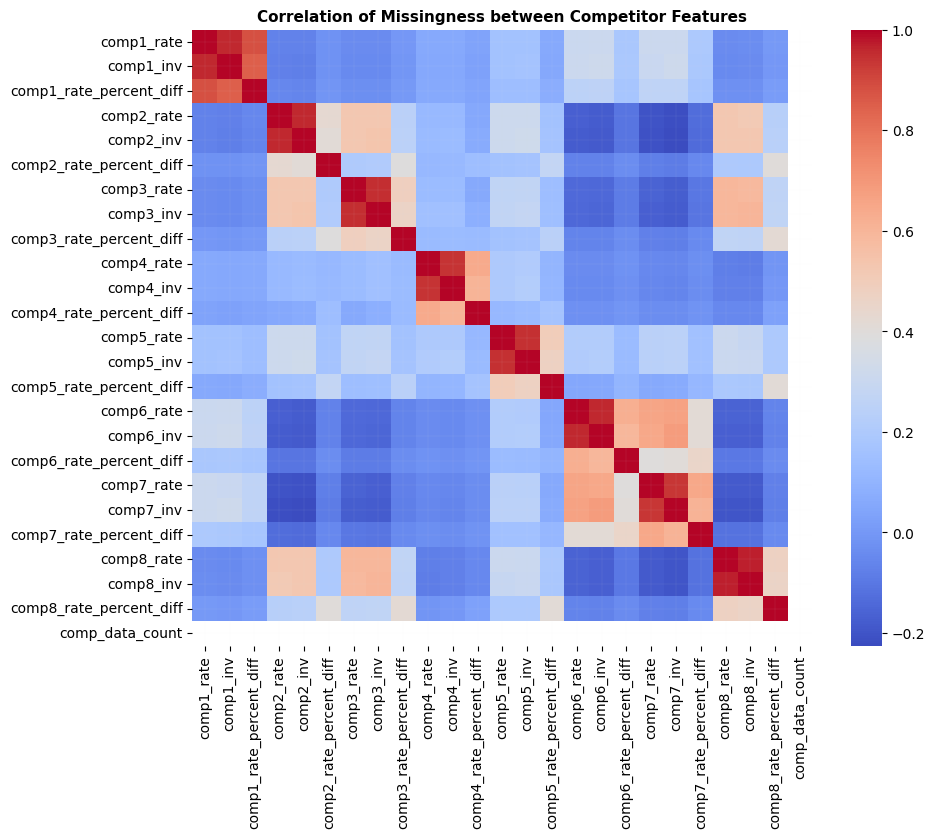

In [13]:
# check if competitor columns are missing simultaneously
comp_cols = [c for c in df.columns if 'comp' in c]
plt.figure(figsize=(10, 8))
sns.heatmap(df[comp_cols].isnull().corr(), annot=False, cmap='coolwarm')
plt.title("Correlation of Missingness between Competitor Features")
plt.show()

In [14]:
# List of highly sparse features from heatmap
sparse_cols = ['visitor_hist_starrating', 'srch_query_affinity_score', 'prop_location_score2']

for col in sparse_cols:
    # Check if the missingness correlates with the booking_bool
    correlation = df[col].isnull().corr(df['booking_bool'])
    print(f"Correlation between {col}_is_missing and booking_bool: {correlation:.4f}")

Correlation between visitor_hist_starrating_is_missing and booking_bool: -0.0115
Correlation between srch_query_affinity_score_is_missing and booking_bool: -0.0101
Correlation between prop_location_score2_is_missing and booking_bool: -0.0472


### Descriptive statistics

In [ ]:
time.sleep(60)

# Select numeric columns for statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculate basic stats
stats = df[numeric_cols].describe().T.rename(columns={"50%": "median"})

# Calculate missing values
stats["missing"] = df[numeric_cols].isnull().sum()
stats["missing %"] = (stats["missing"] / len(df) * 100).round(1)

# Sort by missing % to identify problematic features (Task 3)
stats = stats.sort_values("missing %", ascending=False)
display(stats)

In [ ]:
# plotting key variables identified from literature
important_vars = ["prop_starrating", "prop_review_score", "promotion_flag"]
colors = ['#FF7F50', '#008080', '#FFBF00']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

In [ ]:
# target variables
# plotting key variables identified from literature
important_vars = ["position", "click_bool", "booking_bool"]
colors = ['#FF7F50', '#008080', '#FFBF00']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(df['visitor_location_country_id'], bins =100)
plt.show()

In [ ]:
a = df.loc[df['srch_saturday_night_bool'] == 0, 'price_usd']
b = df.loc[df['srch_saturday_night_bool'] == 1, 'price_usd']
plt.figure(figsize=(20, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Search Non-Sat Night')
plt.hist(b, bins = 50, alpha=0.5, label='Search Sat Night')
plt.legend(loc='upper right')
plt.xlabel('Price\n Price is more stable and lower when searching Non-Saturday night and price goes up when searching Saturday night', fontsize = 18)
plt.ylabel('Count', fontsize = 18)
plt.title("Price Comperision between Non-Saturday Night vs Saturday Night")
plt.show();

In [ ]:
def explore_saturday_stay(data):
    """checking if Saturday night impacts the clicks and bookings"""
    # group by the boolean flag
    stats = data.groupby('srch_saturday_night_bool').agg({
        'click_bool': 'mean',
        'booking_bool': 'mean'
    }).reset_index()

    print("Conversion Rates by Saturday Night Stay:")
    print(stats)

    # plot
    stats_melted = stats.melt(id_vars='srch_saturday_night_bool', value_vars=['click_bool', 'booking_bool'], var_name='Action', value_name='Rate')

    sns.barplot(data=stats_melted, x='srch_saturday_night_bool', y='Rate', hue='Action')
    plt.title('Click and Booking Rates: Saturday Night vs. Non-Saturday')
    plt.ylabel('Proportion')
    plt.show()

explore_saturday_stay(df)

Adding the relevance column to align with the evaluation metric

In [ ]:
# conditions
conditions = [
    (df['booking_bool'] == 1),
    (df['click_bool'] == 1)
]

# Define corresponding relevance grades
choices = [5, 1]

# Default to 0 if neither condition is met
df['relevance'] = np.select(conditions, choices, default=0)

In [ ]:
corr  = df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={"size": 6.5}, ax=ax)
ax.set_title("Correlation matrix (ordered by |correlation| with mood_mean)")
#plt.xticks(fontsize=7,rotation=40)
ax.set_xticklabels(ax.get_xticklabels(),rotation=30, ha="right")
plt.tight_layout()
#plt.savefig("figures/train_correlation_matrix.png", dpi=150)
plt.show()

In [ ]:
print("Shape:", df.shape)
print("Unique users:", df["srch_id"].nunique())

### Promotion flag

In [ ]:
# checking how the promotion flag correlates with the average position
promotion_stats = df.groupby('promotion_flag')['position'].mean().reset_index()

promotion_stats.columns = ['Promotion Flag', 'Average Position']
print(promotion_stats)

We see that the promotion flag means the average position is higher

In [ ]:
# BIAS: we use Independent Samples T-Test to check if this difference is statistically significant - if algorithm promotes discounted hotels
from scipy import stats

# separate data into two groups
group_no_promo = df[df['promotion_flag'] == 0]['position']
group_promo = df[df['promotion_flag'] == 1]['position']

#Welch's T-test
t_stat, p_value = stats.ttest_ind(group_no_promo, group_promo, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("The difference is statistically significant (Reject H0).")
else:
    print("The difference is not statistically significant (Fail to reject H0).")


Since the dataset is very large, even small differences result in a statistically significant result, as in here. we should mention that while statistically significant, the practical significance (the ~2.6 rank jump) is what truly influences the user's likelihood to click or book.

Read to see what are the options:
https://towardsdatascience.com/a-complete-guide-to-recommender-system-tutorial-with-sklearn-surprise-keras-recommender-5e52e8ceace1/

## K-Nearest Neighbours
https://www.geeksforgeeks.org/machine-learning/recommender-systems-using-knn/


Content-Based Recommender System - but we can add use features and make it hybrid

In [ ]:
# 1. feature selection - for now only a few features to see how the model performs
features = [
    'prop_starrating', 'prop_review_score', 'prop_location_score1',
    'prop_location_score2', 'prop_log_historical_price',
    'price_usd', 'promotion_flag'
]

# 2. Preprocessing Pipeline
# extract features and handle missing values/scaling
X = df[features].copy()

# data imputation
imputer = SimpleImputer(strategy='median') #missing values with median
X_processed = imputer.fit_transform(X)

#scaling
scaler = StandardScaler() #scaling
X_scaled = scaler.fit_transform(X_processed)

# 3. train-test split (80-20)
# training set to find centroids; test set to evaluate assignment stability
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)


# Elbow method to find the best k
inertia = []
K_range = range(1, 30)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plotting the Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:

# 4. unsupervised Cross-Validation (inertia stability)
# we use K-Fold to ensure the clusters (inertia) are consistent across different slices of data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_clusters = 30 #change for the optimal
cv_inertia = []

print(f"Starting 5-Fold Cross-Validation for K={k_clusters}...")

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]

    # fit model on the fold training data
    km_fold = KMeans(n_clusters=k_clusters, n_init=5, random_state=42)
    km_fold.fit(X_fold_train)

    # calculate Inertia on the validation fold
    # inertia = sum of squared distances of samples to their closest cluster center
    cv_inertia.append(km_fold.inertia_)

print(f"Average CV Inertia: {np.mean(cv_inertia):.2f} (+/- {np.std(cv_inertia):.2f})")


In [6]:
# 1. feature selection - for now only a few features to see how the model performs
features = [
    'prop_starrating', 'prop_review_score', 'prop_location_score1',
    'prop_location_score2', 'prop_log_historical_price',
    'price_usd', 'promotion_flag'
]

# 2. Preprocessing Pipeline
# extract features and handle missing values/scaling
X = df[features].copy()

# data imputation
imputer = SimpleImputer(strategy='median') #missing values with median
X_processed = imputer.fit_transform(X)

#scaling
scaler = StandardScaler() #scaling
X_scaled = scaler.fit_transform(X_processed)

# 3. train-test split (80-20)
# training set to find centroids; test set to evaluate assignment stability
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# 4. unsupervised Cross-Validation (inertia stability)
# we use K-Fold to ensure the clusters (inertia) are consistent across different slices of data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_clusters = 50
cv_inertia = []

print(f"Starting 5-Fold Cross-Validation for K={k_clusters}...")

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]

    # fit model on the fold training data
    km_fold = KMeans(n_clusters=k_clusters, n_init=5, random_state=42)
    km_fold.fit(X_fold_train)

    # calculate Inertia on the validation fold
    # inertia = sum of squared distances of samples to their closest cluster center
    cv_inertia.append(km_fold.inertia_)

print(f"Average CV Inertia: {np.mean(cv_inertia):.2f} (+/- {np.std(cv_inertia):.2f})")



Starting 5-Fold Cross-Validation for K=50...
Average CV Inertia: 2647813.22 (+/- 20324.80)


In [7]:
# 5. final model implementation
# fitting on the full training set and assigning clusters to the test set
final_kmeans = KMeans(n_clusters=k_clusters, n_init=10, random_state=42)
final_kmeans.fit(X_train)

# assign cluster labels back to the original dataframe for the test indices
train_indices, test_indices = train_test_split(df.index, test_size=0.2, random_state=42)
df.loc[train_indices, 'hotel_cluster'] = final_kmeans.labels_
df.loc[test_indices, 'hotel_cluster'] = final_kmeans.predict(X_test)

print("\nCluster assignment complete. Sample distribution:")
print(df['hotel_cluster'].value_counts().head())


Cluster assignment complete. Sample distribution:
hotel_cluster
17.0    309776
2.0     306708
40.0    294968
43.0    199867
23.0    198242
Name: count, dtype: int64


#### Computing the predicted ranking from the clusters - pointwise ranking
Goal: "rank the properties belonging to a user search on the likeliness that the property will be booked" for each user list all the properites from their search based on the probability that that property will be booked, i.e. highest probability that booking_bool=1

The evaluation function is (NDCG)@5 calculated per query and averaged over all queries with the values weighted by the log_2 function - this rewards ehavily if the acutal booked hotel appears at the very top of our list.

Since K-means is unsupervised, the "Cluster ID" itself doesn't tell "probability." We have to map the clusters to historical booking success. The way to do this:

1. Calculate the *Mean Booking Rate* for each cluster.

2. Assign this "Cluster Score" to every hotel in that cluster.

3. Sort the hotels within each SearchId by that score.


cluster_score - Probability Estimate derived from historical data. total number of bookings in a cluster/total number of hotel listings which were put in that cluster e.g if Cluster 5 has 1,000 hotel listings and 50 of them were booked, its cluster_score is 0.05.

In [10]:
# visualising the differences between the culsters - average attributes for each cluster
cluster_profiles = df.groupby('hotel_cluster')[features + ['booking_bool']].mean()

print("Cluster profiles by booking probability:")
display(cluster_profiles.sort_values(by='booking_bool', ascending=False).head(10)) # sort by booking_bool - most booked clusters

Cluster Profiles (Sorted by Booking Probability):


,prop_starrating,prop_review_score,prop_location_score1,prop_location_score2,prop_log_historical_price,price_usd,promotion_flag,booking_bool
hotel_cluster,,,,,,,,
3.0,2.853198,3.902936,2.253529,0.580634,4.769558,1.290011e+02,0.009174,0.121240
5.0,4.636364,3.954545,3.462727,0.056500,2.006364,4.285486e+06,0.272727,0.090909
20.0,2.868457,4.050294,2.476815,0.259172,4.830187,1.276556e+02,0.000000,0.069983
49.0,3.659463,4.023662,4.782237,0.649141,5.361562,1.921578e+02,1.000000,0.063155
33.0,3.185057,3.783923,3.794737,0.265938,5.007226,1.299185e+02,1.000000,0.061267
36.0,3.639277,4.010657,4.618811,0.448703,0.000000,2.109575e+02,1.000000,0.055184
34.0,4.184211,4.263158,3.245526,0.071414,3.907105,2.552001e+06,0.368421,0.052632
26.0,3.513439,4.074922,4.210516,0.467427,0.000000,2.457806e+02,0.000000,0.049329
18.0,3.962934,4.156162,4.793386,0.375484,5.458065,2.247765e+02,1.000000,0.044785


In [ ]:
# 1. calculate the cluster_score of each cluster based on historical bookings
cluster_weights = df.groupby('hotel_cluster')['booking_bool'].mean().reset_index()
cluster_weights.columns = ['hotel_cluster', 'cluster_score']

# 2. merge this score back to into the df
final_df = df.merge(cluster_weights, on='hotel_cluster', how='left')

# 3. double sorting to handle tie-breakers
# if two hotels are in the same cluster, they have the same cluster_score.
# we use prop_review_score as a secondary sort to break ties - we can consider sorting first by a differnt feature to break ties (for exmaple the location)
final_df = final_df.sort_values(by=['srch_id', 'cluster_score', 'prop_review_score'], ascending=[True, False, False])


# save file
submission.to_csv(f'VU-DM-2026-Group-62-{timestr}.csv', index=False)

print("K-means Ranker Submission Generated.")
print(submission.head(30).to_string(index=False))

##